In [5]:
import pandas as pd
import numpy as np

from collections import Counter
from math import log, exp

import random
import time

In [2]:
df=pd.read_parquet(
  "../Assignment 01/hindi_texts_tokenized.parquet"
)

df.head()

,sentence,words,words_count
0,लोगों को बिलों संबंधी सुविधा देना ही उनका काम,"[लोगों, को, बिलों, संबंधी, सुविधा, देना, ही, उ...",9
1,इनेलो 1987 में उस वक्त ऐसे ही दोराहे पर खड़ी थ...,"[इनेलो, 1987, में, उस, वक्त, ऐसे, ही, दोराहे, ...",29
2,हालांकि तब पार्टी पर देवीलाल की मजबूत पकड़ के ...,"[हालांकि, तब, पार्टी, पर, देवीलाल, की, मजबूत, ...",17
3,1989 में देवीलाल केन्द्र की राजनीति में सक्रिय...,"[1989, में, देवीलाल, केन्द्र, की, राजनीति, में...",48
4,उन परिस्थितियों में देवीलाल ने कड़ा निर्णय लेत...,"[उन, परिस्थितियों, में, देवीलाल, ने, कड़ा, निर...",38


#### Check the Dataframe

In [6]:
print("Number of sentences:", len(df))
print("Number of columns:", len(df.columns))

print("\nColumns:")
print(df.columns.tolist())

Number of sentences: 3035640
Number of columns: 3

Columns:
['sentence', 'words', 'words_count']


#### If any Missing Tokens

In [7]:
print("Missing sentences:", df["sentence"].isna().sum())
print("Missing token lists:", df["words"].isna().sum())

Missing sentences: 0
Missing token lists: 0


#### Splitting Into Train, Test and Development Sets

In [8]:
SEED = 42

np.random.seed(SEED)

N = len(df)

# Randomly select 2000 sentence indices
selected_indices = np.random.choice(
    N,
    size=2000,
    replace=False
)

# development
dev_indices = selected_indices[:1000]

# test
test_indices = selected_indices[1000:]

# training
all_selected = set(selected_indices)

train_indices = [
    i for i in range(N)
    if i not in all_selected
]

print("Total sentences :", N)
print("Training        :", len(train_indices))
print("Development     :", len(dev_indices))
print("Test            :", len(test_indices))

Total sentences : 3035640
Training        : 3033640
Development     : 1000
Test            : 1000


In [9]:
train_df = df.iloc[train_indices].copy()
dev_df = df.iloc[dev_indices].copy()
test_df = df.iloc[test_indices].copy()

print("Training sentences   :", len(train_df))
print("Development sentences:", len(dev_df))
print("Test sentences       :", len(test_df))

Training sentences   : 3033640
Development sentences: 1000
Test sentences       : 1000


#### Function to add Boundary Tokens

In [10]:
START_TOKEN = "<s>"
END_TOKEN = "</s>"
UNK_TOKEN = "<UNK>"


def add_sentence_tokens(tokens):
  """
  Add sentence boundary tokens.
  
  Example:
  [राम, घर, गया]
  
  becomes:
  [<s>, राम, घर, गया, </s>]
  """
  
  return [START_TOKEN] + list(tokens) + [END_TOKEN]

In [11]:
example = ["राम", "घर", "गया"]

print(add_sentence_tokens(example))

['<s>', 'राम', 'घर', 'गया', '</s>']


#### Build the Vocabulary only on the Training Data

In [12]:
print("Building vocabulary...")

start_time = time.time()

vocab_counter = Counter()

for tokens in train_df["words"]:
    vocab_counter.update(tokens)

# Add special tokens
vocab_counter[START_TOKEN] += 1
vocab_counter[END_TOKEN] += 1
vocab_counter[UNK_TOKEN] += 1

vocab = set(vocab_counter.keys())

V = len(vocab)

print("Vocabulary size:", V)
print("Time taken:", round(time.time() - start_time, 2), "seconds")

Building vocabulary...
Vocabulary size: 545854
Time taken: 15.23 seconds


#### Handle Unknown Words

In [13]:
def replace_unknown_words(tokens, vocab):
    """
    Replace words not present in training vocabulary
    with <UNK>.
    """
    
    return [
        word if word in vocab else UNK_TOKEN
        for word in tokens
    ]

In [14]:
example = ["राम", "एकअनोखाशब्द", "घर", "गया"]

print(replace_unknown_words(example, vocab))

['राम', '<UNK>', 'घर', 'गया']


## Unigram Language Model

#### Build Unigram Counts

In [17]:
unigram_counts = Counter()

total_tokens = 0

print("Building unigram model...")

start_time = time.time()

for tokens in train_df["words"]:   
    tokens = add_sentence_tokens(tokens)
    
    # Replace OOV words
    tokens = replace_unknown_words(tokens, vocab)
    
    unigram_counts.update(tokens)
    total_tokens += len(tokens)

print("Total tokens:", total_tokens)
print("Unique unigrams:", len(unigram_counts))
print("Time taken:", round(time.time() - start_time, 2), "seconds")

Building unigram model...
Total tokens: 72441305
Unique unigrams: 545853
Time taken: 26.72 seconds


#### Laplace-Smoothing Unigram Probability

In [20]:
def unigram_probability(word):
    """
    Laplace-smoothed unigram probability:
    
    P(w) = (C(w) + 1) / (N + V)
    """
    
    count = unigram_counts.get(word, 0)
    
    probability = (count + 1) / (total_tokens + V)
    
    return probability

In [21]:
word = "में"

print("Count:", unigram_counts.get(word, 0))
print("Probability:", unigram_probability(word))

Count: 1917684
Probability: 0.026274279287949814


## Bigram Language Model

#### Build Bigram Counts

In [22]:
bigram_counts = Counter()
bigram_context_counts = Counter()

print("Building bigram model...")

start_time = time.time()

for tokens in train_df["words"]:
    tokens = add_sentence_tokens(tokens)
    tokens = replace_unknown_words(tokens, vocab)
    
    # Generate bigrams
    for i in range(len(tokens) - 1):
        w1 = tokens[i]
        w2 = tokens[i + 1]
        
        bigram_counts[(w1, w2)] += 1
        bigram_context_counts[w1] += 1

print("Unique bigrams:", len(bigram_counts))
print("Time taken:", round(time.time() - start_time, 2), "seconds")

Building bigram model...
Unique bigrams: 7723522
Time taken: 80.94 seconds


#### Bigram Laplace Probability

In [23]:
def bigram_probability(w1, w2):
    """
    Laplace-smoothed bigram probability:
    
    P(w2 | w1)
    
    = (C(w1,w2) + 1)
      ----------------
      C(w1) + V
    """
    
    bigram_count = bigram_counts.get((w1, w2), 0)
    context_count = bigram_context_counts.get(w1, 0)
    
    probability = (
        bigram_count + 1
    ) / (
        context_count + V
    )
    
    return probability

In [24]:
w1 = "राम"
w2 = "घर"

print(
    f"P({w2} | {w1}) =",
    bigram_probability(w1, w2)
)

P(घर | राम) = 5.342118149846414e-06


## Trigram Language Model

#### Build Trigram Counts

In [25]:
trigram_counts = Counter()
trigram_context_counts = Counter()

print("Building trigram model...")

start_time = time.time()

for tokens in train_df["words"]:
    tokens = add_sentence_tokens(tokens)
    tokens = replace_unknown_words(tokens, vocab)
    
    for i in range(len(tokens) - 2):
        w1 = tokens[i]
        w2 = tokens[i + 1]
        w3 = tokens[i + 2]
        
        trigram_counts[(w1, w2, w3)] += 1
        
        trigram_context_counts[(w1, w2)] += 1

print("Unique trigrams:", len(trigram_counts))
print("Time taken:", round(time.time() - start_time, 2), "seconds")

Building trigram model...
Unique trigrams: 26029580
Time taken: 137.49 seconds


#### Trigram Laplace probability

In [26]:
def trigram_probability(w1, w2, w3):
    """
    Laplace-smoothed trigram probability:
    
    P(w3 | w1, w2)
    
    = (C(w1,w2,w3) + 1)
      -------------------
      C(w1,w2) + V
    """
    
    trigram_count = trigram_counts.get(
        (w1, w2, w3),
        0
    )
    
    context_count = trigram_context_counts.get(
        (w1, w2),
        0
    )
    
    probability = (
        trigram_count + 1
    ) / (
        context_count + V
    )
    
    return probability

In [ ]:
print(
    trigram_probability(
        "राम",
        "घर",
        "गया"
    )
)

## Quadrigram Language Model

#### Build quadrigram counts

In [27]:
quadrigram_counts = Counter()
quadrigram_context_counts = Counter()

print("Building quadrigram model...")

start_time = time.time()

for tokens in train_df["words"]:
    tokens = add_sentence_tokens(tokens)
    tokens = replace_unknown_words(tokens, vocab)
    
    for i in range(len(tokens) - 3):  
        w1 = tokens[i]
        w2 = tokens[i + 1]
        w3 = tokens[i + 2]
        w4 = tokens[i + 3]
        
        quadrigram_counts[(w1, w2, w3, w4)] += 1
        
        quadrigram_context_counts[(w1, w2, w3)] += 1

print("Unique quadrigrams:", len(quadrigram_counts))
print("Time taken:", round(time.time() - start_time, 2), "seconds")

Building quadrigram model...
Unique quadrigrams: 42140419
Time taken: 245.24 seconds


#### Quadrigram Laplace probability

In [28]:
def quadrigram_probability(w1, w2, w3, w4):
    """
    Laplace-smoothed quadrigram probability:
    
    P(w4 | w1,w2,w3)
    
    = (C(w1,w2,w3,w4) + 1)
      -----------------------
      C(w1,w2,w3) + V
    """
    
    quadrigram_count = quadrigram_counts.get(
        (w1, w2, w3, w4),
        0
    )
    
    context_count = quadrigram_context_counts.get(
        (w1, w2, w3),
        0
    )
    
    probability = (
        quadrigram_count + 1
    ) / (
        context_count + V
    )
    
    return probability

In [29]:
print(
    quadrigram_probability(
        "राम",
        "घर",
        "गया",
        "लोगों"
    )
)

1.831991704741561e-06


### Evaluation Functions

#### Unigram evaluation

In [30]:
def evaluate_unigram(dataset):
    total_log_prob = 0.0
    total_predictions = 0
    
    for tokens in dataset["words"]:
        tokens = add_sentence_tokens(tokens)
        tokens = replace_unknown_words(tokens, vocab)
        
        for word in tokens:
            total_log_prob += log(
                unigram_probability(word)
            )
            
            total_predictions += 1
    
    perplexity = exp(
        -total_log_prob / total_predictions
    )
    
    return perplexity

#### Bigram Evaluation

In [31]:
def evaluate_bigram(dataset):
    total_log_prob = 0.0
    total_predictions = 0
    
    for tokens in dataset["words"]:
        tokens = add_sentence_tokens(tokens)
        tokens = replace_unknown_words(tokens, vocab)
        
        for i in range(len(tokens) - 1):
            w1 = tokens[i]
            w2 = tokens[i + 1]
            
            total_log_prob += log(
                bigram_probability(w1, w2)
            )
            
            total_predictions += 1
    
    perplexity = exp(
        -total_log_prob / total_predictions
    )
    
    return perplexity

#### Trigram Evaluation

In [33]:
def evaluate_trigram(dataset):
    total_log_prob = 0.0
    total_predictions = 0
    
    for tokens in dataset["words"]:
        tokens = add_sentence_tokens(tokens)
        tokens = replace_unknown_words(tokens, vocab)
        
        for i in range(len(tokens) - 2):
            w1 = tokens[i]
            w2 = tokens[i + 1]
            w3 = tokens[i + 2]
            
            total_log_prob += log(
                trigram_probability(w1, w2, w3)
            )
            
            total_predictions += 1
    
    perplexity = exp(
        -total_log_prob / total_predictions
    )
    
    return perplexity

## Quadrigram evaluation

In [ ]:
def evaluate_quadrigram(dataset):
    total_log_prob = 0.0
    total_predictions = 0
    
    for tokens in dataset["words"]:
        tokens = add_sentence_tokens(tokens)
        tokens = replace_unknown_words(tokens, vocab)
        
        for i in range(len(tokens) - 3):
            w1 = tokens[i]
            w2 = tokens[i + 1]
            w3 = tokens[i + 2]
            w4 = tokens[i + 3]
            
            total_log_prob += log(
                quadrigram_probability(
                    w1, w2, w3, w4
                )
            )
            
            total_predictions += 1
    
    perplexity = exp(
        -total_log_prob / total_predictions
    )
    
    return perplexity

In [35]:
print("Evaluating models on development set...\n")

dev_unigram_pp = evaluate_unigram(dev_df)

print("Unigram Perplexity :", dev_unigram_pp)

dev_bigram_pp = evaluate_bigram(dev_df)

print("Bigram Perplexity  :", dev_bigram_pp)

dev_trigram_pp = evaluate_trigram(dev_df)

print("Trigram Perplexity :", dev_trigram_pp)

dev_quadrigram_pp = evaluate_quadrigram(dev_df)

print("Quadrigram Perplexity:",
      dev_quadrigram_pp)

Evaluating models on development set...

Unigram Perplexity : 1275.9011927557874
Bigram Perplexity  : 2212.2836934932197
Trigram Perplexity : 31274.650549588518
Quadrigram Perplexity: 154988.3300024809


In [36]:
print("Evaluating models on test set...\n")

test_unigram_pp = evaluate_unigram(test_df)

print("Unigram Perplexity :", test_unigram_pp)

test_bigram_pp = evaluate_bigram(test_df)

print("Bigram Perplexity  :", test_bigram_pp)

test_trigram_pp = evaluate_trigram(test_df)

print("Trigram Perplexity :", test_trigram_pp)

test_quadrigram_pp = evaluate_quadrigram(test_df)

print("Quadrigram Perplexity:",
      test_quadrigram_pp)

Evaluating models on test set...

Unigram Perplexity : 1178.8404903918902
Bigram Perplexity  : 2015.072996593839
Trigram Perplexity : 29490.22880312492
Quadrigram Perplexity: 154389.89666987146


In [37]:
results = pd.DataFrame({
    "Model": [
        "Unigram",
        "Bigram",
        "Trigram",
        "Quadrigram"
    ],
    
    "Development Perplexity": [
        dev_unigram_pp,
        dev_bigram_pp,
        dev_trigram_pp,
        dev_quadrigram_pp
    ],
    
    "Test Perplexity": [
        test_unigram_pp,
        test_bigram_pp,
        test_trigram_pp,
        test_quadrigram_pp
    ]
})

results

,Model,Development Perplexity,Test Perplexity
0,Unigram,1275.901193,1178.840490
1,Bigram,2212.283693,2015.072997
2,Trigram,31274.650550,29490.228803
3,Quadrigram,154988.330002,154389.896670


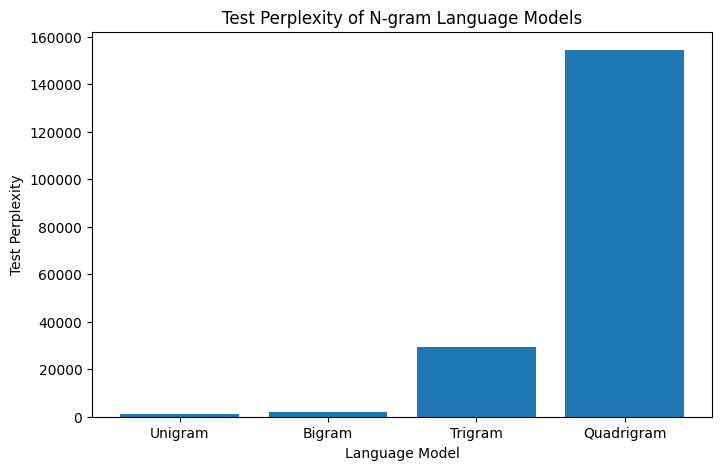

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    results["Model"],
    results["Test Perplexity"]
)

plt.xlabel("Language Model")
plt.ylabel("Test Perplexity")
plt.title("Test Perplexity of N-gram Language Models")

plt.show()